In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

from flax import nnx

In [3]:
from diffusion_mri_models import Dti, Ball, Stick, add_mri_noise

In [380]:
class BallAndStick(nnx.Module, experimental_pytree=True):
    
    def __init__(self,num_sticks: int, rngs):
        self.num_sticks = num_sticks
        self.num_components = 1 + num_sticks + 1 # Ball + Sticks + Noise
        # Ball parameters
        self.theta_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))
        self.phi_ball = nnx.Param(jax.random.normal(rngs.next(), (1)))

        self.thetas_stick = []
        self.phis_stick = []
    
        for i in range(num_sticks):
            self.thetas_stick.append(nnx.Param(jax.random.normal(rngs.next(), (3))))
            if i < num_sticks-1:
                self.phis_stick.append(nnx.Param(jax.random.normal(rngs.next(), (1))))

        self.theta_sigma = nnx.Param(jax.random.normal(rngs.next(), (1)))

        

    def __call__(self, component_mask, bvals, bvecs, rng):
        ball = Ball.from_theta(self.theta_ball.value)
        sticks = [Stick.from_theta(theta) for theta in self.thetas_stick]

        phi0 = jax.nn.sigmoid(self.phi_ball.value) * component_mask[0]
        S_ball = ball.signal(bvals, bvecs) * phi0

        S_total = S_ball

        for i, stick in enumerate(sticks[:-1]):
            phi_i =  jax.nn.sigmoid(self.phis_stick[i].value) * (1-phi0) * component_mask[i+1]
            phi0 += phi_i # update the total volume fraction
            S_total += stick.signal(bvals, bvecs)*phi_i

        # Last stick
        if len(sticks) > 0:
            S_total += sticks[-1].signal(bvals, bvecs) * (1-phi0) * component_mask[-2]

        std = jax.nn.sigmoid(self.theta_sigma.value)*0.2 * component_mask[-1]
        S_noisy = add_mri_noise(rng,S_total, std)

        return S_noisy


In [381]:
simulator = BallAndStick(2, nnx.Rngs(0))

bvals = jax.random.uniform(jax.random.key(0), (100,), minval=100, maxval=3000)
bvecs = jax.random.normal(jax.random.key(1), (100,3))
component_mask = jnp.array([1]*simulator.num_components)
component_mask

Array([1, 1, 1, 1], dtype=int32)

In [382]:
s = simulator(component_mask, bvals, bvecs, jax.random.key(0))

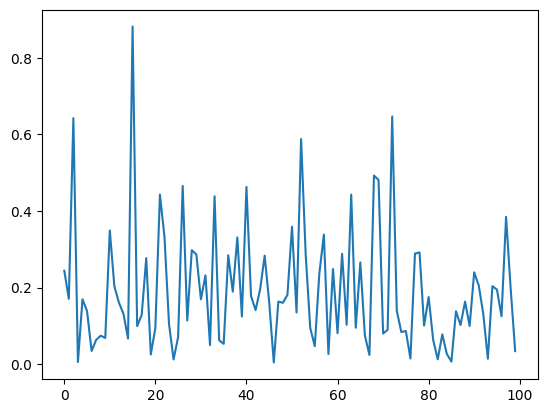

In [383]:
plt.plot(s)

In [384]:
graphdef, thetas = nnx.split(simulator, nnx.Param)
flat_thetas, unflatten = jax.flatten_util.ravel_pytree(thetas)


NUM_AQUISITIONS = 100

def generate_data(key, bvals, bvecs):
    rng_component_mask, rng_params, rng_simulator = jax.random.split(key,3)
    component_mask = jax.random.bernoulli(rng_component_mask, 0.5, (simulator.num_components,))
    params = jax.random.normal(rng_params, flat_thetas.shape)
    params = unflatten(params)
    f = nnx.merge(graphdef, params)
    S = f(component_mask, bvals, bvecs, rng_simulator)
    return component_mask, params, S




In [385]:
theta_list = jax.tree_util.tree_flatten(thetas)[0]

theta_list

[Array([-1.401], dtype=float32),
 Array([0.676], dtype=float32),
 Array([1.88], dtype=float32),
 Array([0.306], dtype=float32),
 Array([-0.795,  0.763, -0.3  ], dtype=float32),
 Array([-0.41 ,  0.113, -0.509], dtype=float32)]

In [376]:
from functools import partial

bvals = jax.random.uniform(jax.random.key(0), (100,), minval=100, maxval=3000)
bvecs = jax.random.normal(jax.random.key(1), (100,3))

@partial(jax.jit, static_argnums=(1,))  
def batch_sampler(key, batch_size=512):
    keys = jax.random.split(key, batch_size)
    components, thetas, signal= jax.vmap(lambda k:generate_data(k, bvals,bvecs))(keys)
    xs = signal.reshape((batch_size, -1))
    return components, thetas, xs

def train_data_generator(key, batch_size):
    while True:
        key, subkey = jax.random.split(key)
        yield batch_sampler(subkey, batch_size)

train_data = train_data_generator(jax.random.PRNGKey(0), 512)

In [357]:
std = sum([next(train_data)[2].std(0) for _ in range(1000)])/1000
mu = sum([next(train_data)[2].mean(0) for _ in range(1000)])/1000

def z_score(x):
    return (x - mu)/std

In [358]:
from models import ModelIdentificationDecoder, MLP

In [359]:
embedding_net = MLP([NUM_AQUISITIONS, 100,50], rngs=nnx.Rngs(0))
decoder = ModelIdentificationDecoder(50,50, rngs=nnx.Rngs(1), num_heads=4, num_layers=4, widening_factor=4, context_net=embedding_net)


class Model(nnx.Module, experimental_pytree=True):
    def __init__(self, num_components,decoder):
        self.decoder = decoder
        self.num_components = num_components
    def __call__(self, components, thetas, x_o):
        x_o = z_score(x_o)
        logits = self.decoder(components, x_o)
        return logits
    
    def sample_components(self,rng, num_samples,x_o):
        rngs = jax.random.split(rng, num_samples)
        return jax.vmap(self.decoder.sample, in_axes=(0,None,None))(rngs, x_o, self.num_components)

model = Model(4,decoder)
params = nnx.state(model, nnx.Param)

In [360]:
components, thetas, xs = next(train_data)

In [361]:
xs.shape

(512, 100)

In [362]:
import optax 

optimizer = optax.adamw(1e-4)

@jax.jit
def loss_fn(params, data):
    nnx.update(model, params)
    components, thetas, xs = data

    logits = model(components,thetas, xs)

    return optax.sigmoid_binary_cross_entropy(logits, components).mean()

@jax.jit
def update(params, opt_state, data):
    grads = jax.grad(loss_fn)(params, data)
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state



In [363]:
opt_state = optimizer.init(params)

In [369]:
for i in range(10_000):
    data = next(train_data)
    params, opt_state = update(params, opt_state, data)
    if i % 100 == 0:
        print(loss_fn(params, data))

0.2854163
0.27796683
0.28727168
0.30016384
0.29090762
0.28367904
0.29097354
0.29728445
0.29880276
0.28528178
0.29136235
0.28544313
0.29800582
0.29827404
0.29133743
0.2887842
0.29315668
0.29757804
0.27492082
0.28105924
0.28411543
0.28603137
0.292873
0.27980146
0.27452055
0.2901776
0.28442657
0.28290257
0.28828582
0.2807836
0.27579963
0.27669826
0.27510035
0.28198662
0.28007773
0.29150093
0.29789293
0.2903344
0.29139104
0.28405023
0.2996378
0.28681812
0.2911476
0.29176867
0.29139853
0.2732399
0.29355413
0.27872413
0.28123486
0.28886878
0.2883163
0.28550404
0.29377064
0.28490406
0.3100434
0.2823081
0.28698972
0.28416753
0.28647137
0.28884673
0.2854494
0.29267925
0.29004872
0.28668362
0.2902037
0.26898438
0.29649806
0.28999123
0.3017515
0.28089562
0.27871597
0.28890356
0.28804135
0.28529096
0.29290122
0.2715876
0.28219163
0.29346344
0.27335295
0.28593862
0.28123063
0.29340726
0.2836877
0.27695733
0.27840167
0.28421038
0.2885219
0.28049344
0.2924312
0.2920468
0.27455014
0.27398676
0.2823278

In [365]:
nnx.update(model, params)

In [366]:
components, thetas, xs = next(train_data)

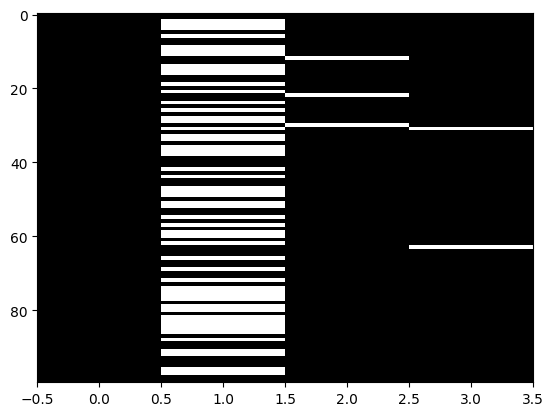

In [391]:
components_pred = model.sample_components(jax.random.PRNGKey(4),100, xs[15])

plt.imshow(components_pred, aspect='auto', cmap="Greys")


In [390]:
components[15]

Array([ True,  True,  True, False], dtype=bool)